In [1]:
import sys
sys.path.append('..')
import nimo
import yaml
import shutil

In [2]:
# Parameters cell for papermill
config_file = "nts_settings.tmpl.yaml"  # This will be overwritten by papermill

In [3]:
# Parameters
config_file = "./configs/nts_conservative_batch48_trial4.yaml"


In [4]:
# Load configuration from YAML file
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

### AIとロボットのサイクルの回数を設定

In [5]:
# CyclesNum will be calculated from total_eval / batch_size

### 目的関数の次元を設定

In [6]:
ObjectivesNum = config["objectives_num"]

In [7]:
from descriptor import Desctiptor
des = Desctiptor()

### 実験条件候補データファイル名および提案条件のファイル名を設定

In [8]:
from pathlib import Path

TRIAL = config["trial"]
BATCH_SIZE = int(config["batch_size"])
TOTAL_EVAL = int(config["total_eval"])
INITIAL_BATCH_SIZE = int(config["initial_batch_size"])
CyclesNum = int((TOTAL_EVAL - INITIAL_BATCH_SIZE) / BATCH_SIZE)
print(f"CyclesNum: {CyclesNum}")
NTS_MODE = config["nts_mode"]
RE_SEED = config["re_seed"]
USE_DPP = config["use_dpp"]

if NTS_MODE == "conservative":
    MODE = nimo.Mode.conservative
elif NTS_MODE == "moderate":
    MODE = nimo.Mode.moderate
elif NTS_MODE == "aggressive":
    MODE = nimo.Mode.aggressive
print(MODE)

# Create output directory with batch size in name
out_dir = Path(f"./data_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}")
out_dir.mkdir(exist_ok=True, parents=True)
(out_dir / "fig").mkdir(exist_ok=True, parents=True)

# Copy setting yaml file to output directory
shutil.copy(config_file, out_dir / Path(config_file).name)

CyclesNum: 14
Mode.conservative


PosixPath('data_conservative_batch48_trial4/nts_conservative_batch48_trial4.yaml')

In [9]:
candidates_file = out_dir / f"descriptor_search_space_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"
proposals_file = out_dir / f"descriptor_proposals_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"

# Copy initial search space to output directory if not exists
import os
initial_search_space = f"./descriptor_search_space_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"
if os.path.exists(initial_search_space) and not os.path.exists(candidates_file):
    shutil.copy(initial_search_space, candidates_file)

### 結果を格納する場所を作成

In [10]:
res_history = nimo.history(input_file = str(candidates_file),
                             num_objectives = ObjectivesNum)

### 最適化計算

In [11]:
import time
start = time.time()
for K in range(CyclesNum+1):

    #最初のサイクルではランダムに実験条件を提案させる
    if K == 0:
        nimo.selection(method = "RE",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = INITIAL_BATCH_SIZE,
                       re_seed = RE_SEED)

    #2回目以降のサイクルではAIを使用して実験条件を提案
    else:
        nimo.selection(method = "NTS",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = BATCH_SIZE,
                       sample_mode=MODE,
                       use_dpp=USE_DPP,
                       output_res=True)

    #実験条件に従い，ロボット実験のインプットファイルを作成する
    import preparation_input_functions
    preparation_input_functions.ORIGINAL(input_file = str(proposals_file),
                                         input_folder = str(out_dir)).perform()

    #実験終了後，測定データを解析し，目的関数をアップデートする
    import analysis_output_functions_SO_descriptor
    analysis_output_functions_SO_descriptor.ORIGINAL(input_file = str(proposals_file),
                                       output_file = str(candidates_file),
                                       num_objectives = ObjectivesNum,
                                       output_folder = str(out_dir)).perform()

    #結果をプロットするためのhistoryを格納する
    res_history = nimo.history(input_file = str(candidates_file),
                               num_objectives = ObjectivesNum,
                               itt = K,
                               history_file = res_history)

    #結果のヒストグラムを作成するモジュールを読み出す
    if K % 5 == 0:
        import time
        time.sleep(1)
        nimo.visualization.plot_distribution.plot(input_file = str(candidates_file),
                                                  num_objectives = ObjectivesNum,
                                                  fig_folder = str(out_dir / "fig"))

end = time.time()
print(f"Elapsed time: {end - start} [s]")

Start selection of proposals by RE!


Proposals
###
number = 1
actions =  6971
proposal =  [2.6 1.2 1.5]
###
###
number = 2
actions =  10353
proposal =  [3.6 1.3 3. ]
###
###
number = 3
actions =  16184
proposal =  [3.2 1.5 1.5]
###
###
number = 4
actions =  6363
proposal =  [0.9 1.2 3.6]
###
###
number = 5
actions =  13028
proposal =  [2.8 1.4 0.4]
###
###
number = 6
actions =  13663
proposal =  [4.5 1.4 1. ]
###
###
number = 7
actions =  5558
proposal =  [6.9 1.1 0.8]
###
###
number = 8
actions =  6344
proposal =  [0.9 1.2 1.7]
###
###
number = 9
actions =  13816
proposal =  [4.9 1.4 1.5]
###
###
number = 10
actions =  7526
proposal =  [4.1 1.2 1.5]
###
###
number = 11
actions =  6006
proposal =  [0.  1.2 1.2]
###
###
number = 12
actions =  15171
proposal =  [0.5 1.5 0.1]
###
###
number = 13
actions =  13639
proposal =  [4.4 1.4 2.3]
###
###
number = 14
actions =  12567
proposal =  [1.5 1.4 2.4]
###
###
number = 15
actions =  9101
proposal =  [0.2 1.3 3.6]
###
###
number = 16
actions =  12390
proposal =  [1.  1.4 3.2]
##

Start selection of proposals by NTS!
--------------------------------------------------------------------------------
         Use physbo.search.discrete.Policy instead.
--------------------------------------------------------------------------------


lstar: 1.1531379482000002


Selected actions: [np.int64(17732), np.int64(5332), np.int64(13772), np.int64(11831), np.int64(1733), np.int64(7287), np.int64(12886), np.int64(9000), np.int64(14374), np.int64(6773), np.int64(17478), np.int64(17185), np.int64(1763), np.int64(17301), np.int64(4926), np.int64(17525), np.int64(17197), np.int64(17293), np.int64(16878), np.int64(2133), np.int64(12521), np.int64(14898), np.int64(11484), np.int64(5927), np.int64(9658), np.int64(13971), np.int64(16343), np.int64(11710), np.int64(14920), np.int64(14069), np.int64(3521), np.int64(7176), np.int64(11189), np.int64(16641), np.int64(14703), np.int64(3155), np.int64(14785), np.int64(1867), np.int64(17584), np.int64(7214), np.int64(17635), np.int64(16270), np.int64(17871), np.int64(7584), np.int64(2280), np.int64(1854), np.int64(14680), np.int64(4373)]
Proposals
###
number = 1
actions =  17732
proposal =  [7.4 1.5 0.9]
###
###
number = 2
actions =  5332
proposal =  [6.3 1.1 0.4]
###
###
number = 3
actions =  13772
proposal =  [4.8 1.

...

lstar: 1.1859301858


Selected actions: [np.int64(17624), np.int64(15056), np.int64(6205), np.int64(17976), np.int64(6014), np.int64(10553), np.int64(15071), np.int64(4930), np.int64(15085), np.int64(12440), np.int64(16971), np.int64(16793), np.int64(15207), np.int64(16517), np.int64(14091), np.int64(1582), np.int64(14995), np.int64(16156), np.int64(12016), np.int64(6005), np.int64(17981), np.int64(100), np.int64(5986), np.int64(343), np.int64(16742), np.int64(17470), np.int64(15326), np.int64(17674), np.int64(2590), np.int64(17471), np.int64(16280), np.int64(15069), np.int64(16094), np.int64(12050), np.int64(17940), np.int64(12049), np.int64(17178), np.int64(15033), np.int64(10943), np.int64(17831), np.int64(17029), np.int64(11975), np.int64(4514), np.int64(16592), np.int64(17059), np.int64(11343), np.int64(11701), np.int64(17757)]
Proposals
###
number = 1
actions =  17624
proposal =  [7.1 1.5 1.2]
###
###
number = 2
actions =  15056
proposal =  [0.1 1.5 3.4]
###
###
number = 3
actions =  6205
proposal =  

lstar: 1.1903726702


Selected actions: [np.int64(570), np.int64(8170), np.int64(4164), np.int64(15395), np.int64(12091), np.int64(7813), np.int64(14551), np.int64(12545), np.int64(17640), np.int64(4660), np.int64(13717), np.int64(17529), np.int64(15067), np.int64(16769), np.int64(1600), np.int64(17538), np.int64(8207), np.int64(10544), np.int64(14046), np.int64(17617), np.int64(17430), np.int64(8965), np.int64(15610), np.int64(16712), np.int64(4456), np.int64(15053), np.int64(10851), np.int64(14425), np.int64(17083), np.int64(4795), np.int64(13831), np.int64(8140), np.int64(14035), np.int64(12055), np.int64(14813), np.int64(11858), np.int64(17943), np.int64(1140), np.int64(14728), np.int64(15837), np.int64(4320), np.int64(1983), np.int64(11571), np.int64(11984), np.int64(16710), np.int64(16189), np.int64(14180), np.int64(15884)]
Proposals
###
number = 1
actions =  570
proposal =  [1.5 1.  1.5]
###
###
number = 2
actions =  8170
proposal =  [5.8 1.2 3. ]
###
###
number = 3
actions =  4164
proposal =  [3.1 1

Elapsed time: 33050.49101805687 [s]


### 目的関数の推移を出力

In [12]:
nimo.visualization.plot_history.cycle(input_file = res_history,
                                      num_cycles = CyclesNum,
                                      fig_folder = str(out_dir / "fig"))

In [13]:
import numpy as np
tmp = []
X_tmp = []
for r in res_history:
    tmp.append(r[2][0])
    X_tmp.append(r[1])

tmp = np.array(tmp)
X_tmp = np.array(X_tmp)

In [14]:
from collections import defaultdict
sample_by_iter, objective_by_iter = defaultdict(list), defaultdict(list)
for r in res_history:
    objective_by_iter[r[0]].append(r[2][0])
    sample_by_iter[r[0]].append(r[1])

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15])


Text(0, 0.5, 'Objective')

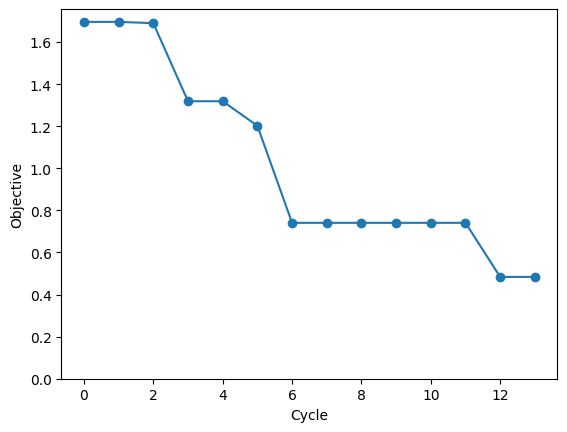

In [15]:
import matplotlib.pyplot as plt

print(objective_by_iter.keys())

fig, ax = plt.subplots()
tmp_history = [des.get_regret(max(objective_by_iter[1]))]
for i in range(1, CyclesNum):
    tmp_history.append(min(tmp_history[-1], des.get_regret(max(objective_by_iter[i]))))
ax.plot(range(CyclesNum), tmp_history, marker="o")
ax.set_xlabel("Cycle")
ax.set_ylim(0)
ax.set_ylabel("Objective")

In [16]:
# Save nested list object
import pickle
with open(out_dir / "objective_by_iter.pkl", "wb") as f:
    pickle.dump(objective_by_iter, f)
with open(out_dir / "sample_by_iter.pkl", "wb") as f:
    pickle.dump(sample_by_iter, f)